# CYMO Feature Exploration & Selection

CYMO returned 344 linguistic metrics for each utterance in the ParkCeleb dataset.  
This notebook explores those features and applies multiple feature selection methods  
to identify the 20–30 most discriminative features for PD vs CN classification.

### Feature selection methods covered
| Method | Type | How it works |
|--------|------|--------------|
| Mann-Whitney U test | Filter (univariate) | Tests if PD and CN distributions differ significantly |
| Cohen's d | Filter (effect size) | Measures how large the group difference is |
| Variance threshold | Filter | Removes features with near-zero variance (no information) |
| Correlation pruning | Filter | Removes redundant features that are highly correlated |
| Random Forest importance | Embedded | Uses a trained model to rank features by predictive power |
| Mutual Information | Filter | Measures how much each feature tells us about the label |

---

In [1]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CHANGE THESE PATHS                                        ║
# ╚══════════════════════════════════════════════════════════════╝

CYMO_CSV    = '../ParkCeleb/ann.cymo_parkceleb.csv'         # CYMO output
META_CSV    = '../ParkCeleb/cymo_parkceleb_metadata.csv'    # metadata from converter script

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 10,
    'axes.titlesize': 11, 'axes.titleweight': 'bold',
})
print('Imports OK')

Imports OK


---
## 1 — Load and merge data

In [3]:
# ============================================================
# 1.1  Load CYMO results
# ============================================================
cymo = pd.read_csv(CYMO_CSV)
print(f'CYMO results:  {cymo.shape[0]} rows × {cymo.shape[1]} columns')
print(f'First column:  {cymo.columns[0]}')
print(f'Feature columns: {cymo.shape[1] - 1}')

# Identify TID column (might be 'TID' or first column)
tid_col = 'TID' if 'TID' in cymo.columns else cymo.columns[0]
feature_cols = [c for c in cymo.columns if c != tid_col]
print(f'\nTID column: "{tid_col}"')
print(f'Number of feature columns: {len(feature_cols)}')
print(f'\nFirst 10 feature names:')
for c in feature_cols[:10]:
    print(f'  {c}')

CYMO results:  149546 rows × 346 columns
First column:  TID
Feature columns: 345

TID column: "TID"
Number of feature columns: 345

First 10 feature names:
  wid
  MLS
  MLC
  MLT
  CS
  CT
  cTT
  dCC
  dCT
  cPC


In [4]:
# ============================================================
# 1.2  Load metadata and merge
# ============================================================
meta = pd.read_csv(META_CSV)
print(f'Metadata:  {meta.shape[0]} rows × {meta.shape[1]} columns')
print(f'Columns: {list(meta.columns)}')

# Merge on TID
meta_tid_col = 'TID' if 'TID' in meta.columns else meta.columns[0]
df = cymo.merge(meta[[meta_tid_col, 'group', 'subject', 'video_id',
                       'years_from_diagnosis', 'before_after']].drop_duplicates(),
                left_on=tid_col, right_on=meta_tid_col, how='inner')

print(f'\nMerged: {len(df)} rows')
print(f'  CN: {len(df[df["group"]=="CN"])} utterances')
print(f'  PD: {len(df[df["group"]=="PD"])} utterances')

# Encode label
df['label'] = (df['group'] == 'PD').astype(int)  # 1=PD, 0=CN

Metadata:  144099 rows × 11 columns
Columns: ['TID', 'text', 'group', 'subject', 'video_id', 'segment_idx', 'start_s', 'end_s', 'target_speaker', 'years_from_diagnosis', 'before_after']

Merged: 149546 rows
  CN: 82826 utterances
  PD: 66720 utterances


---
## 2 — Data quality overview

In [5]:
# ============================================================
# 2.1  Missing values
# ============================================================
missing = df[feature_cols].isnull().sum()
missing_pct = missing / len(df) * 100

print(f'Missing value analysis across {len(feature_cols)} features:')
print(f'  Features with 0% missing   : {(missing_pct == 0).sum()}')
print(f'  Features with <5% missing  : {(missing_pct < 5).sum()}')
print(f'  Features with 5-50% missing: {((missing_pct >= 5) & (missing_pct < 50)).sum()}')
print(f'  Features with >50% missing : {(missing_pct > 50).sum()}')

high_missing = missing_pct[missing_pct > 50].sort_values(ascending=False)
if len(high_missing) > 0:
    print(f'\n  Features with >50% missing (will be dropped):')
    for feat, pct in high_missing.head(15).items():
        print(f'    {feat:<40s} {pct:.1f}% missing')

Missing value analysis across 345 features:
  Features with 0% missing   : 345
  Features with <5% missing  : 345
  Features with 5-50% missing: 0
  Features with >50% missing : 0


In [6]:
# ============================================================
# 2.2  Drop features with too many missing values, then fill rest
# ============================================================
# Drop features with >50% missing
keep_cols = missing_pct[missing_pct <= 50].index.tolist()
dropped = [c for c in feature_cols if c not in keep_cols]

print(f'Keeping {len(keep_cols)} features (dropped {len(dropped)} with >50% missing)')

# Convert to numeric, fill remaining NaN with column median
for col in keep_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[keep_cols] = df[keep_cols].fillna(df[keep_cols].median())

# Update feature list
feature_cols = keep_cols
print(f'Working feature set: {len(feature_cols)} features')

Keeping 345 features (dropped 0 with >50% missing)
Working feature set: 345 features


In [7]:
# ============================================================
# 2.3  Variance check — remove near-zero variance features
# ============================================================
variances = df[feature_cols].var()
zero_var = variances[variances < 1e-10]

print(f'Features with near-zero variance: {len(zero_var)}')
if len(zero_var) > 0:
    print(f'  Dropping: {list(zero_var.index[:10])}' + ('...' if len(zero_var) > 10 else ''))
    feature_cols = [c for c in feature_cols if c not in zero_var.index]
    print(f'  Remaining features: {len(feature_cols)}')

Features with near-zero variance: 0


---
## 3 — Univariate analysis: which features differ between PD and CN?

For each feature, we compute:
- **Mann-Whitney U test** — non-parametric test for group differences (p-value)
- **Cohen's d** — standardised effect size (how big is the difference)
- **Direction** — whether PD has higher or lower values than CN

In [8]:
# ============================================================
# 3.1  Compute univariate statistics for every feature
# ============================================================
cn_df = df[df['group'] == 'CN']
pd_df = df[df['group'] == 'PD']

results = []

for feat in feature_cols:
    cn_vals = cn_df[feat].dropna()
    pd_vals = pd_df[feat].dropna()
    
    if len(cn_vals) < 10 or len(pd_vals) < 10:
        continue
    
    # Mann-Whitney U test
    try:
        u_stat, p_val = stats.mannwhitneyu(cn_vals, pd_vals, alternative='two-sided')
    except Exception:
        p_val = 1.0
    
    # Cohen's d
    n1, n2 = len(cn_vals), len(pd_vals)
    pooled_std = np.sqrt(((n1-1)*cn_vals.var() + (n2-1)*pd_vals.var()) / (n1+n2-2))
    d = (pd_vals.mean() - cn_vals.mean()) / pooled_std if pooled_std > 0 else 0
    
    results.append({
        'feature': feat,
        'cn_mean': cn_vals.mean(),
        'pd_mean': pd_vals.mean(),
        'cn_std': cn_vals.std(),
        'pd_std': pd_vals.std(),
        'cohens_d': d,
        'abs_d': abs(d),
        'p_value': p_val,
        'direction': 'PD higher' if d > 0 else 'PD lower',
    })

uni_df = pd.DataFrame(results).sort_values('abs_d', ascending=False).reset_index(drop=True)

# Multiple comparison correction (Bonferroni)
n_tests = len(uni_df)
uni_df['p_bonferroni'] = np.minimum(uni_df['p_value'] * n_tests, 1.0)
uni_df['significant'] = uni_df['p_bonferroni'] < 0.05

n_sig = uni_df['significant'].sum()
print(f'Univariate analysis complete: {len(uni_df)} features tested')
print(f'Significant after Bonferroni correction: {n_sig}')
print(f'\nTop 30 features by effect size (|Cohen\'s d|):')
print(f'{"Rank":<5s} {"Feature":<40s} {"Cohen d":>9s} {"p-value":>12s} {"Sig":>5s} {"Direction":>12s}')
print('─' * 90)
for i, row in uni_df.head(30).iterrows():
    sig = '***' if row['p_bonferroni'] < 0.001 else '**' if row['p_bonferroni'] < 0.01 else '*' if row['p_bonferroni'] < 0.05 else ''
    print(f'{i+1:<5d} {row["feature"]:<40s} {row["cohens_d"]:>+9.3f} {row["p_bonferroni"]:>12.2e} {sig:>5s} {row["direction"]:>12s}')

Univariate analysis complete: 345 features tested
Significant after Bonferroni correction: 271

Top 30 features by effect size (|Cohen's d|):
Rank  Feature                                    Cohen d      p-value   Sig    Direction
──────────────────────────────────────────────────────────────────────────────────────────
1     VCCOCAw                                     -0.241     1.53e-17   ***     PD lower
2     VCCOCAa                                     -0.239     3.48e-24   ***     PD lower
3     KLDCOCAw                                    -0.224     1.00e+00           PD lower
4     KLDCOCAa                                    -0.223     9.86e-39   ***     PD lower
5     T20KCOCAs                                   +0.216     1.22e-84   ***    PD higher
6     T30KCOCAs                                   +0.213    3.78e-146   ***    PD higher
7     VCCOCAs                                     -0.213     1.00e+00           PD lower
8     T40KCOCAs                                   +0.21

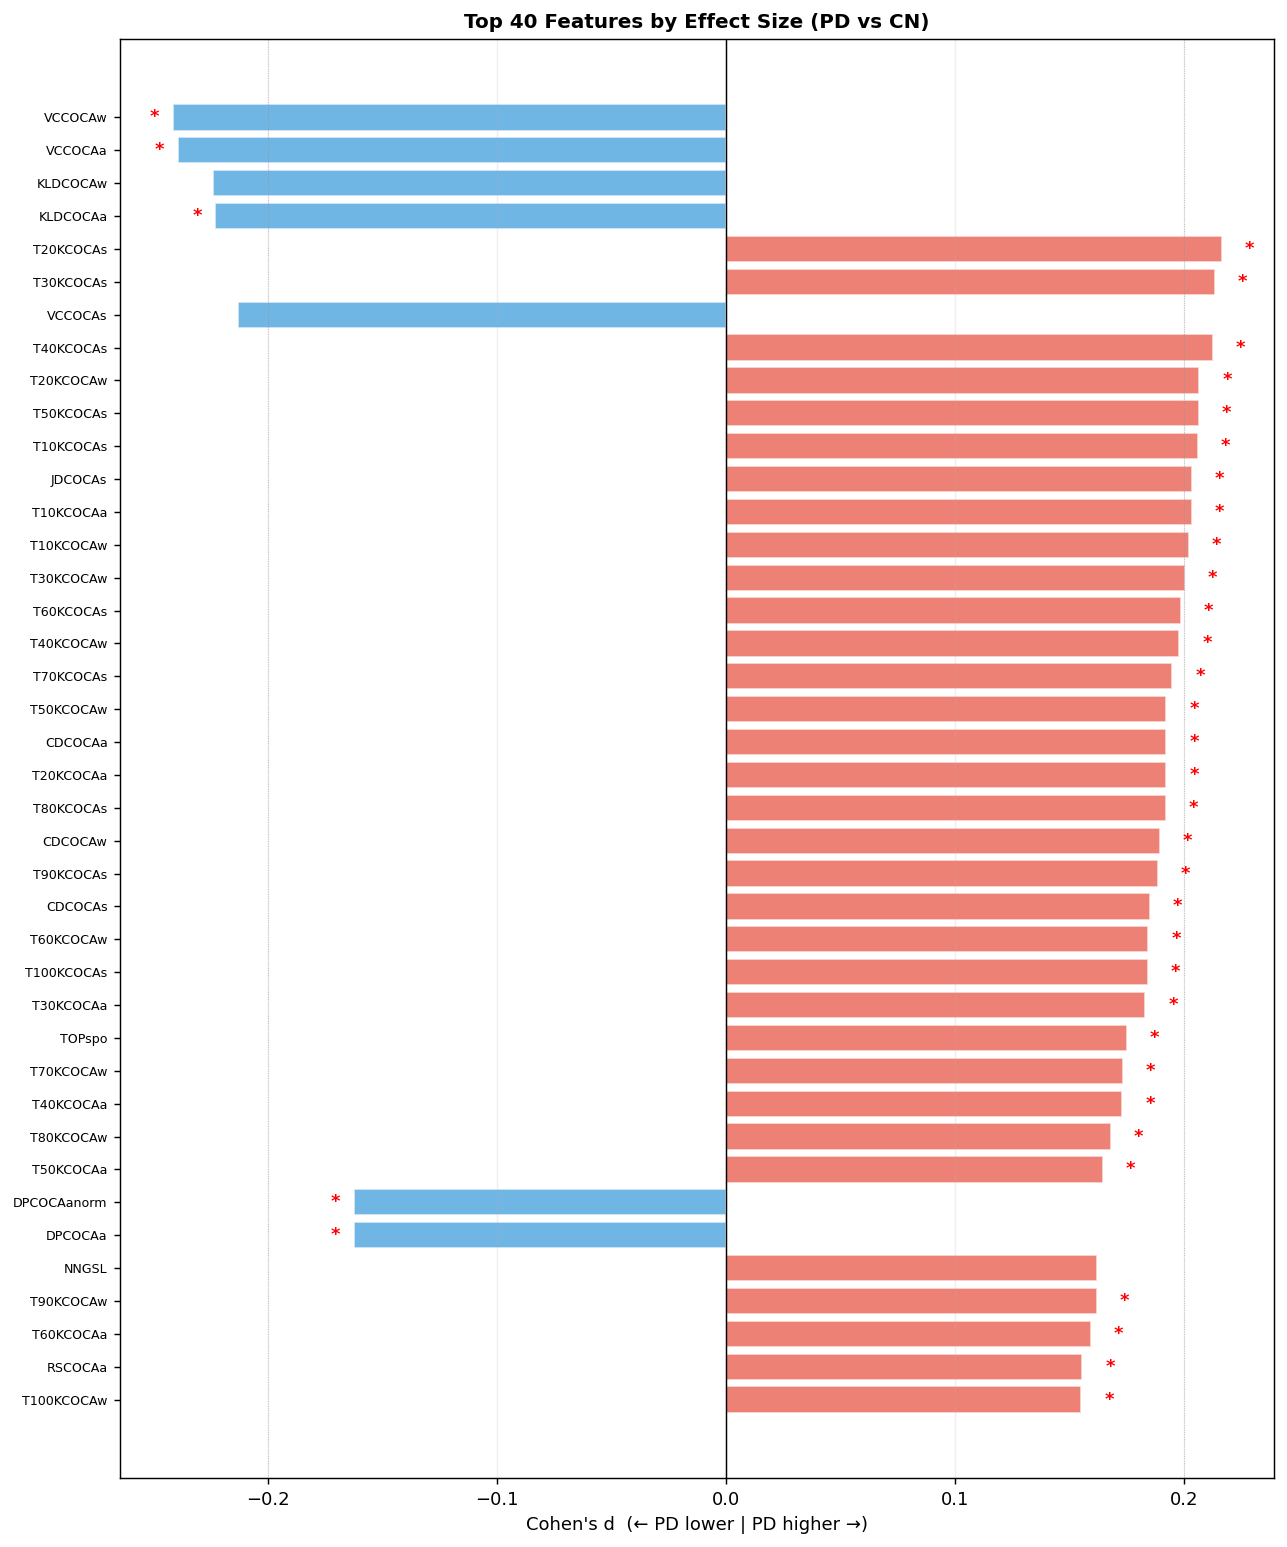

In [9]:
# ============================================================
# 3.2  Visualise top features by effect size
# ============================================================
top_n = min(40, len(uni_df))
top = uni_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.3)))

colors = ['#E74C3C' if d > 0 else '#3498DB' for d in top['cohens_d']]
bars = ax.barh(range(top_n), top['cohens_d'], color=colors, alpha=0.7, edgecolor='white')

ax.set_yticks(range(top_n))
ax.set_yticklabels(top['feature'], fontsize=7)
ax.set_xlabel("Cohen's d  (← PD lower | PD higher →)")
ax.set_title(f'Top {top_n} Features by Effect Size (PD vs CN)')
ax.axvline(0, color='black', lw=0.8)
ax.axvline(0.2, color='gray', ls=':', lw=0.5, alpha=0.5)
ax.axvline(-0.2, color='gray', ls=':', lw=0.5, alpha=0.5)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.2)

# Mark significant features
for i, (_, row) in enumerate(top.iterrows()):
    if row['significant']:
        ax.text(row['cohens_d'] + 0.01 * np.sign(row['cohens_d']),
                i, '*', fontsize=10, va='center', color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('cymo_top_features_effect_size.png', dpi=150, bbox_inches='tight')
plt.show()

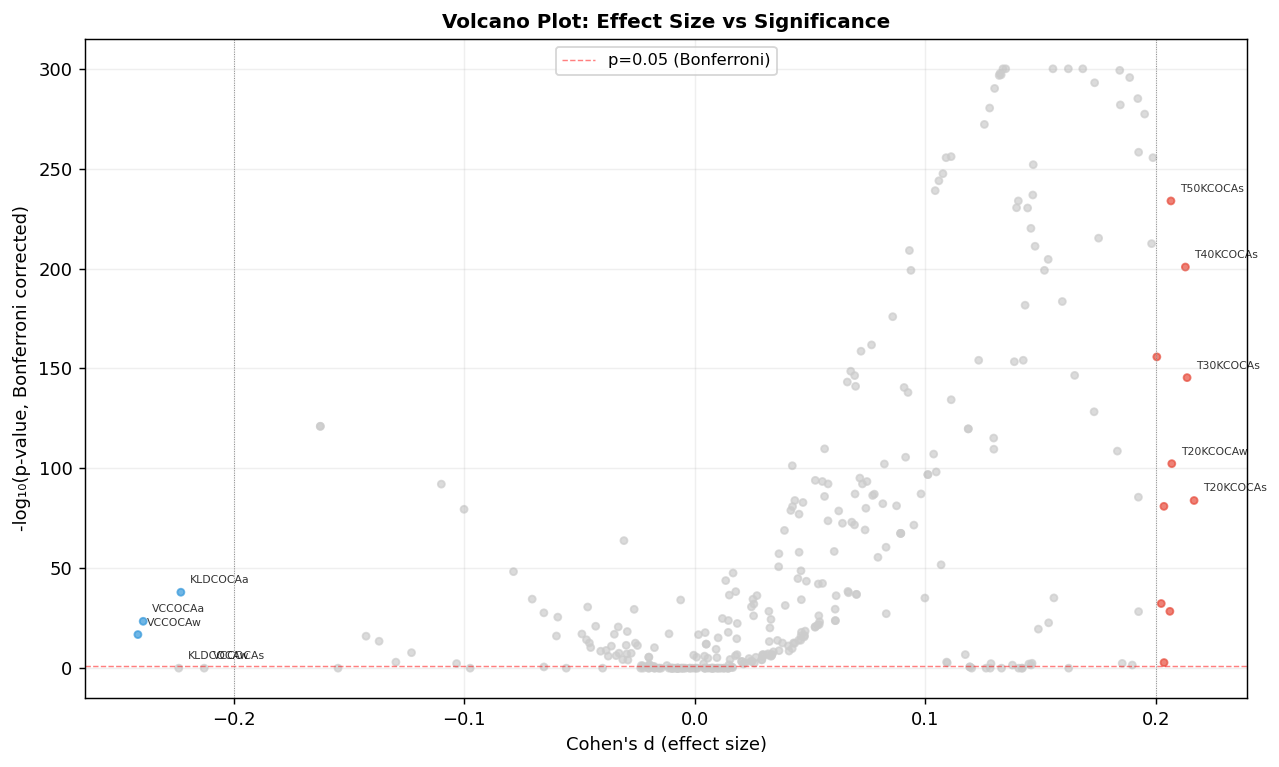

Features that are both significant AND have |d| >= 0.2: 13


In [10]:
# ============================================================
# 3.3  Volcano plot: effect size vs significance
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

neg_log_p = -np.log10(uni_df['p_bonferroni'].clip(lower=1e-300))

# Color by significance and effect size
colors = []
for _, row in uni_df.iterrows():
    if row['p_bonferroni'] < 0.05 and abs(row['cohens_d']) >= 0.2:
        colors.append('#E74C3C' if row['cohens_d'] > 0 else '#3498DB')
    else:
        colors.append('#CCCCCC')

ax.scatter(uni_df['cohens_d'], neg_log_p, c=colors, s=15, alpha=0.7)

# Significance threshold line
ax.axhline(-np.log10(0.05), color='red', ls='--', lw=0.8, alpha=0.5, label='p=0.05 (Bonferroni)')
ax.axvline(0.2, color='gray', ls=':', lw=0.5)
ax.axvline(-0.2, color='gray', ls=':', lw=0.5)

# Label top features
for _, row in uni_df.head(10).iterrows():
    nlp = -np.log10(max(row['p_bonferroni'], 1e-300))
    ax.annotate(row['feature'], (row['cohens_d'], nlp),
                fontsize=6, alpha=0.8,
                xytext=(5, 5), textcoords='offset points')

ax.set_xlabel("Cohen's d (effect size)")
ax.set_ylabel('-log₁₀(p-value, Bonferroni corrected)')
ax.set_title('Volcano Plot: Effect Size vs Significance')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('cymo_volcano_plot.png', dpi=150, bbox_inches='tight')
plt.show()

n_interesting = ((uni_df['p_bonferroni'] < 0.05) & (uni_df['abs_d'] >= 0.2)).sum()
print(f'Features that are both significant AND have |d| >= 0.2: {n_interesting}')

---
## 4 — Correlation analysis: remove redundant features

Many of the 344 CYMO features measure related things and will be highly correlated.  
If two features have correlation > 0.90, they carry almost identical information,  
so we keep the one with the larger effect size and drop the other.

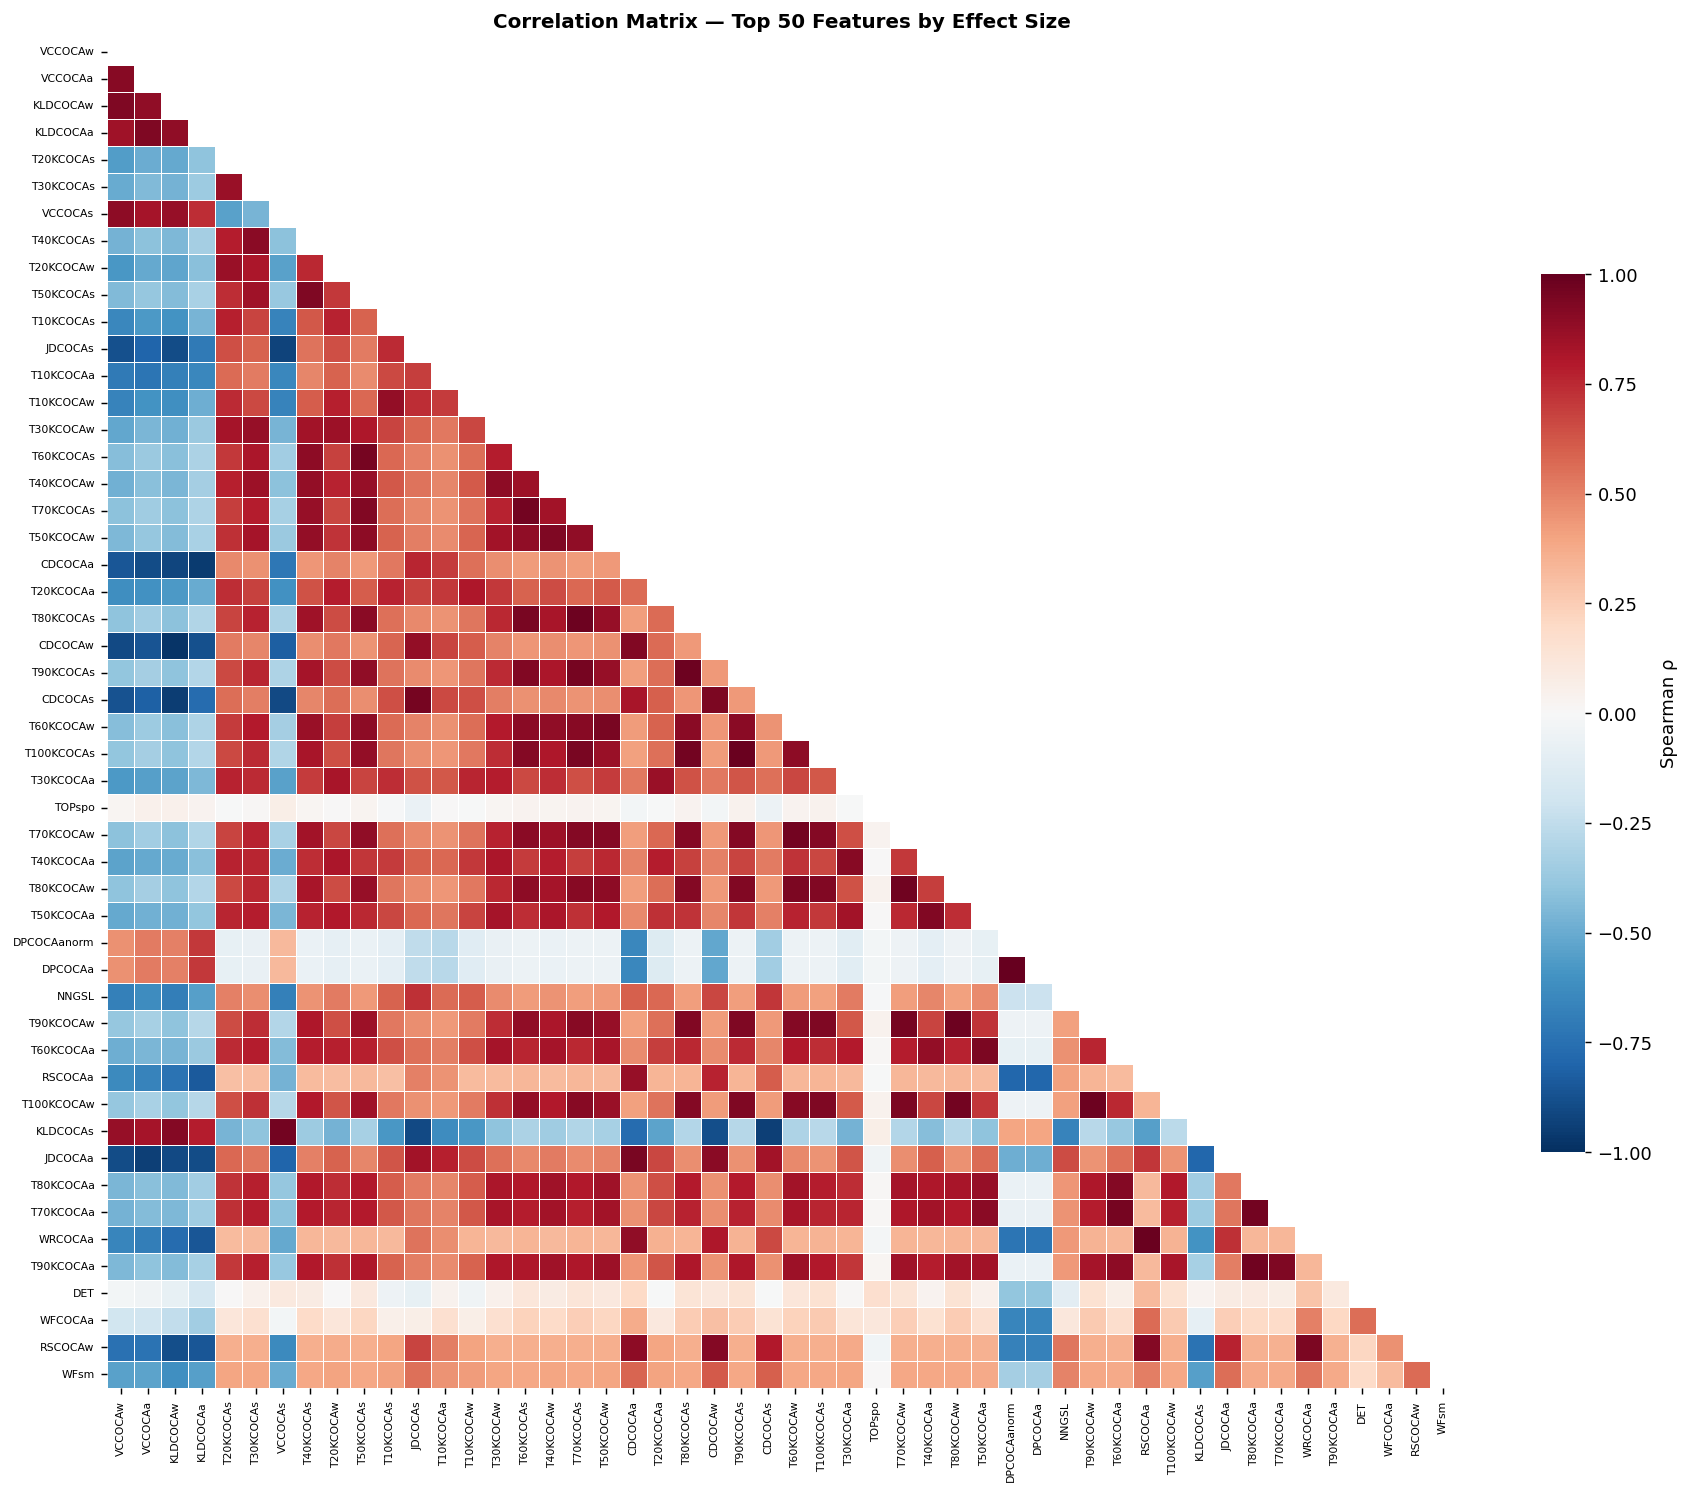

In [11]:
# ============================================================
# 4.1  Correlation matrix of top 50 features
# ============================================================
top50 = uni_df.head(50)['feature'].tolist()

corr_matrix = df[top50].corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.3,
            xticklabels=True, yticklabels=True, ax=ax,
            cbar_kws={'shrink': 0.6, 'label': 'Spearman ρ'})
ax.set_title('Correlation Matrix — Top 50 Features by Effect Size')
ax.tick_params(axis='both', labelsize=6)

plt.tight_layout()
plt.savefig('cymo_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ============================================================
# 4.2  Prune highly correlated features
# ============================================================
CORR_THRESHOLD = 0.85

# Start with all features ranked by effect size
ranked_features = uni_df['feature'].tolist()

# Compute full correlation matrix
full_corr = df[ranked_features].corr(method='spearman').abs()

# Greedy pruning: iterate features by rank, drop later-ranked features
# that are too correlated with already-selected ones
selected = []
dropped_corr = []

for feat in ranked_features:
    # Check if this feature is too correlated with any already-selected feature
    too_correlated = False
    for sel in selected:
        if feat in full_corr.index and sel in full_corr.columns:
            if full_corr.loc[feat, sel] > CORR_THRESHOLD:
                too_correlated = True
                dropped_corr.append((feat, sel, full_corr.loc[feat, sel]))
                break
    
    if not too_correlated:
        selected.append(feat)

print(f'Correlation pruning (threshold: {CORR_THRESHOLD}):')
print(f'  Started with : {len(ranked_features)} features')
print(f'  Dropped      : {len(dropped_corr)} (too correlated with a higher-ranked feature)')
print(f'  Remaining    : {len(selected)} features')

if dropped_corr:
    print(f'\n  Examples of dropped pairs:')
    for feat, kept, corr in dropped_corr[:10]:
        print(f'    Dropped {feat:<35s} (ρ={corr:.2f} with {kept})')

Correlation pruning (threshold: 0.85):
  Started with : 345 features
  Dropped      : 151 (too correlated with a higher-ranked feature)
  Remaining    : 194 features

  Examples of dropped pairs:
    Dropped VCCOCAa                             (ρ=0.91 with VCCOCAw)
    Dropped KLDCOCAw                            (ρ=0.93 with VCCOCAw)
    Dropped T30KCOCAs                           (ρ=0.86 with T20KCOCAs)
    Dropped VCCOCAs                             (ρ=0.89 with VCCOCAw)
    Dropped T20KCOCAw                           (ρ=0.86 with T20KCOCAs)
    Dropped T50KCOCAs                           (ρ=0.94 with T40KCOCAs)
    Dropped JDCOCAs                             (ρ=0.88 with VCCOCAw)
    Dropped T10KCOCAw                           (ρ=0.88 with T10KCOCAs)
    Dropped T60KCOCAs                           (ρ=0.90 with T40KCOCAs)
    Dropped T40KCOCAw                           (ρ=0.88 with T40KCOCAs)


---
## 5 — Model-based feature selection

Train a Random Forest on all features and extract feature importances.  
This captures non-linear relationships that univariate tests miss.

In [13]:
# ============================================================
# 5.1  Random Forest feature importance
# ============================================================

# Use the correlation-pruned features
X = df[selected].values
y = df['label'].values

# Handle any remaining NaN
X = np.nan_to_num(X, nan=0.0)

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X, y)

# Extract importances
rf_importance = pd.DataFrame({
    'feature': selected,
    'rf_importance': rf.feature_importances_,
}).sort_values('rf_importance', ascending=False).reset_index(drop=True)

print('Random Forest feature importances (top 30):')
for i, row in rf_importance.head(30).iterrows():
    bar = '█' * int(row['rf_importance'] * 200)
    print(f'  {i+1:>3d}. {row["feature"]:<40s} {row["rf_importance"]:.4f}  {bar}')

Random Forest feature importances (top 30):
    1. KLDCOCAa                                 0.0487  █████████
    2. DPCOCAanorm                              0.0348  ██████
    3. VCCOCAw                                  0.0345  ██████
    4. T20KCOCAs                                0.0332  ██████
    5. T40KCOCAs                                0.0327  ██████
    6. TOPent                                   0.0324  ██████
    7. TOPspo                                   0.0313  ██████
    8. T10KCOCAa                                0.0292  █████
    9. DPCOCAsnorm                              0.0275  █████
   10. RSCOCAs                                  0.0275  █████
   11. WFsm                                     0.0270  █████
   12. T80KCOCAs                                0.0254  █████
   13. T30KCOCAw                                0.0234  ████
   14. T10KCOCAs                                0.0214  ████
   15. CLI                                      0.0212  ████
   16. B2KBANC     

In [14]:
# ============================================================
# 5.2  Mutual Information
# ============================================================
mi_scores = mutual_info_classif(X, y, random_state=42)

mi_df = pd.DataFrame({
    'feature': selected,
    'mi_score': mi_scores,
}).sort_values('mi_score', ascending=False).reset_index(drop=True)

print('\nMutual Information scores (top 30):')
for i, row in mi_df.head(30).iterrows():
    bar = '█' * int(row['mi_score'] * 100)
    print(f'  {i+1:>3d}. {row["feature"]:<40s} {row["mi_score"]:.4f}  {bar}')


Mutual Information scores (top 30):
    1. T80KCOCAs                                0.0249  ██
    2. T20KCOCAs                                0.0248  ██
    3. T40KCOCAs                                0.0244  ██
    4. VCCOCAw                                  0.0241  ██
    5. KLDCOCAa                                 0.0241  ██
    6. 1GNLFn                                   0.0239  ██
    7. WFsm                                     0.0238  ██
    8. T30KCOCAw                                0.0224  ██
    9. T80KCOCAa                                0.0224  ██
   10. T10KCOCAs                                0.0222  ██
   11. T40KCOCAa                                0.0215  ██
   12. T20KCOCAa                                0.0211  ██
   13. WFCOCAs                                  0.0204  ██
   14. T10KCOCAa                                0.0203  ██
   15. WFCOCAa                                  0.0194  █
   16. RSCOCAs                                  0.0166  █
   17. vVAR1         

---
## 6 — Combine rankings into a consensus selection

Each method gives a different ranking. We combine them by computing  
a **consensus rank** — features that rank highly across multiple methods  
are the most robust candidates.

In [15]:
# ============================================================
# 6.1  Merge all rankings
# ============================================================

# Get rank from each method (only for features that survived correlation pruning)
effect_rank = uni_df[uni_df['feature'].isin(selected)][['feature', 'abs_d']].copy()
effect_rank['rank_effect'] = effect_rank['abs_d'].rank(ascending=False).astype(int)

rf_rank = rf_importance.copy()
rf_rank['rank_rf'] = rf_rank['rf_importance'].rank(ascending=False).astype(int)

mi_rank = mi_df.copy()
mi_rank['rank_mi'] = mi_rank['mi_score'].rank(ascending=False).astype(int)

# Merge
consensus = effect_rank[['feature', 'rank_effect']].merge(
    rf_rank[['feature', 'rank_rf']], on='feature', how='outer'
).merge(
    mi_rank[['feature', 'rank_mi']], on='feature', how='outer'
)

# Average rank (lower = better)
consensus['avg_rank'] = consensus[['rank_effect', 'rank_rf', 'rank_mi']].mean(axis=1)
consensus = consensus.sort_values('avg_rank').reset_index(drop=True)

# Add effect size and direction for reference
consensus = consensus.merge(
    uni_df[['feature', 'cohens_d', 'p_bonferroni', 'direction', 'significant']],
    on='feature', how='left'
)

print(f'Consensus ranking (top 35):')
print(f'{"#":<4s} {"Feature":<40s} {"EffRank":>8s} {"RF Rank":>8s} {"MI Rank":>8s} {"AvgRank":>8s} {"d":>7s} {"Sig":>4s}')
print('─' * 100)
for i, row in consensus.head(35).iterrows():
    sig = '*' if row.get('significant', False) else ''
    print(f'{i+1:<4d} {row["feature"]:<40s} '
          f'{row["rank_effect"]:>8.0f} {row["rank_rf"]:>8.0f} {row["rank_mi"]:>8.0f} '
          f'{row["avg_rank"]:>8.1f} {row["cohens_d"]:>+7.3f} {sig:>4s}')

Consensus ranking (top 35):
#    Feature                                   EffRank  RF Rank  MI Rank  AvgRank       d  Sig
────────────────────────────────────────────────────────────────────────────────────────────────────
1    KLDCOCAa                                        2        1        5      2.7  -0.223    *
2    VCCOCAw                                         1        3        4      2.7  -0.241    *
3    T20KCOCAs                                       3        4        2      3.0  +0.216    *
4    T40KCOCAs                                       4        5        3      4.0  +0.213    *
5    T80KCOCAs                                       9       12        1      7.3  +0.192    *
6    T10KCOCAa                                       6        8       14      9.3  +0.203    *
7    T30KCOCAw                                       7       13        8      9.3  +0.200    *
8    T10KCOCAs                                       5       14       10      9.7  +0.206    *
9    WFsm       

In [16]:
# ============================================================
# 6.2  Select the final 25 features
# ============================================================
N_SELECT = 25  # adjust this: 20-30 as professor suggested

final_features = consensus.head(N_SELECT)['feature'].tolist()

print(f'\nFinal {N_SELECT} selected features:')
print('=' * 60)
for i, feat in enumerate(final_features):
    row = consensus[consensus['feature'] == feat].iloc[0]
    print(f'  {i+1:>2d}. {feat:<40s} d={row["cohens_d"]:>+.3f}  {row["direction"]}')


Final 25 selected features:
   1. KLDCOCAa                                 d=-0.223  PD lower
   2. VCCOCAw                                  d=-0.241  PD lower
   3. T20KCOCAs                                d=+0.216  PD higher
   4. T40KCOCAs                                d=+0.213  PD higher
   5. T80KCOCAs                                d=+0.192  PD higher
   6. T10KCOCAa                                d=+0.203  PD higher
   7. T30KCOCAw                                d=+0.200  PD higher
   8. T10KCOCAs                                d=+0.206  PD higher
   9. WFsm                                     d=+0.146  PD higher
  10. DPCOCAanorm                              d=-0.162  PD lower
  11. T40KCOCAa                                d=+0.173  PD higher
  12. 1GNLFn                                   d=+0.135  PD higher
  13. T80KCOCAa                                d=+0.153  PD higher
  14. T20KCOCAa                                d=+0.192  PD higher
  15. WFCOCAa                       

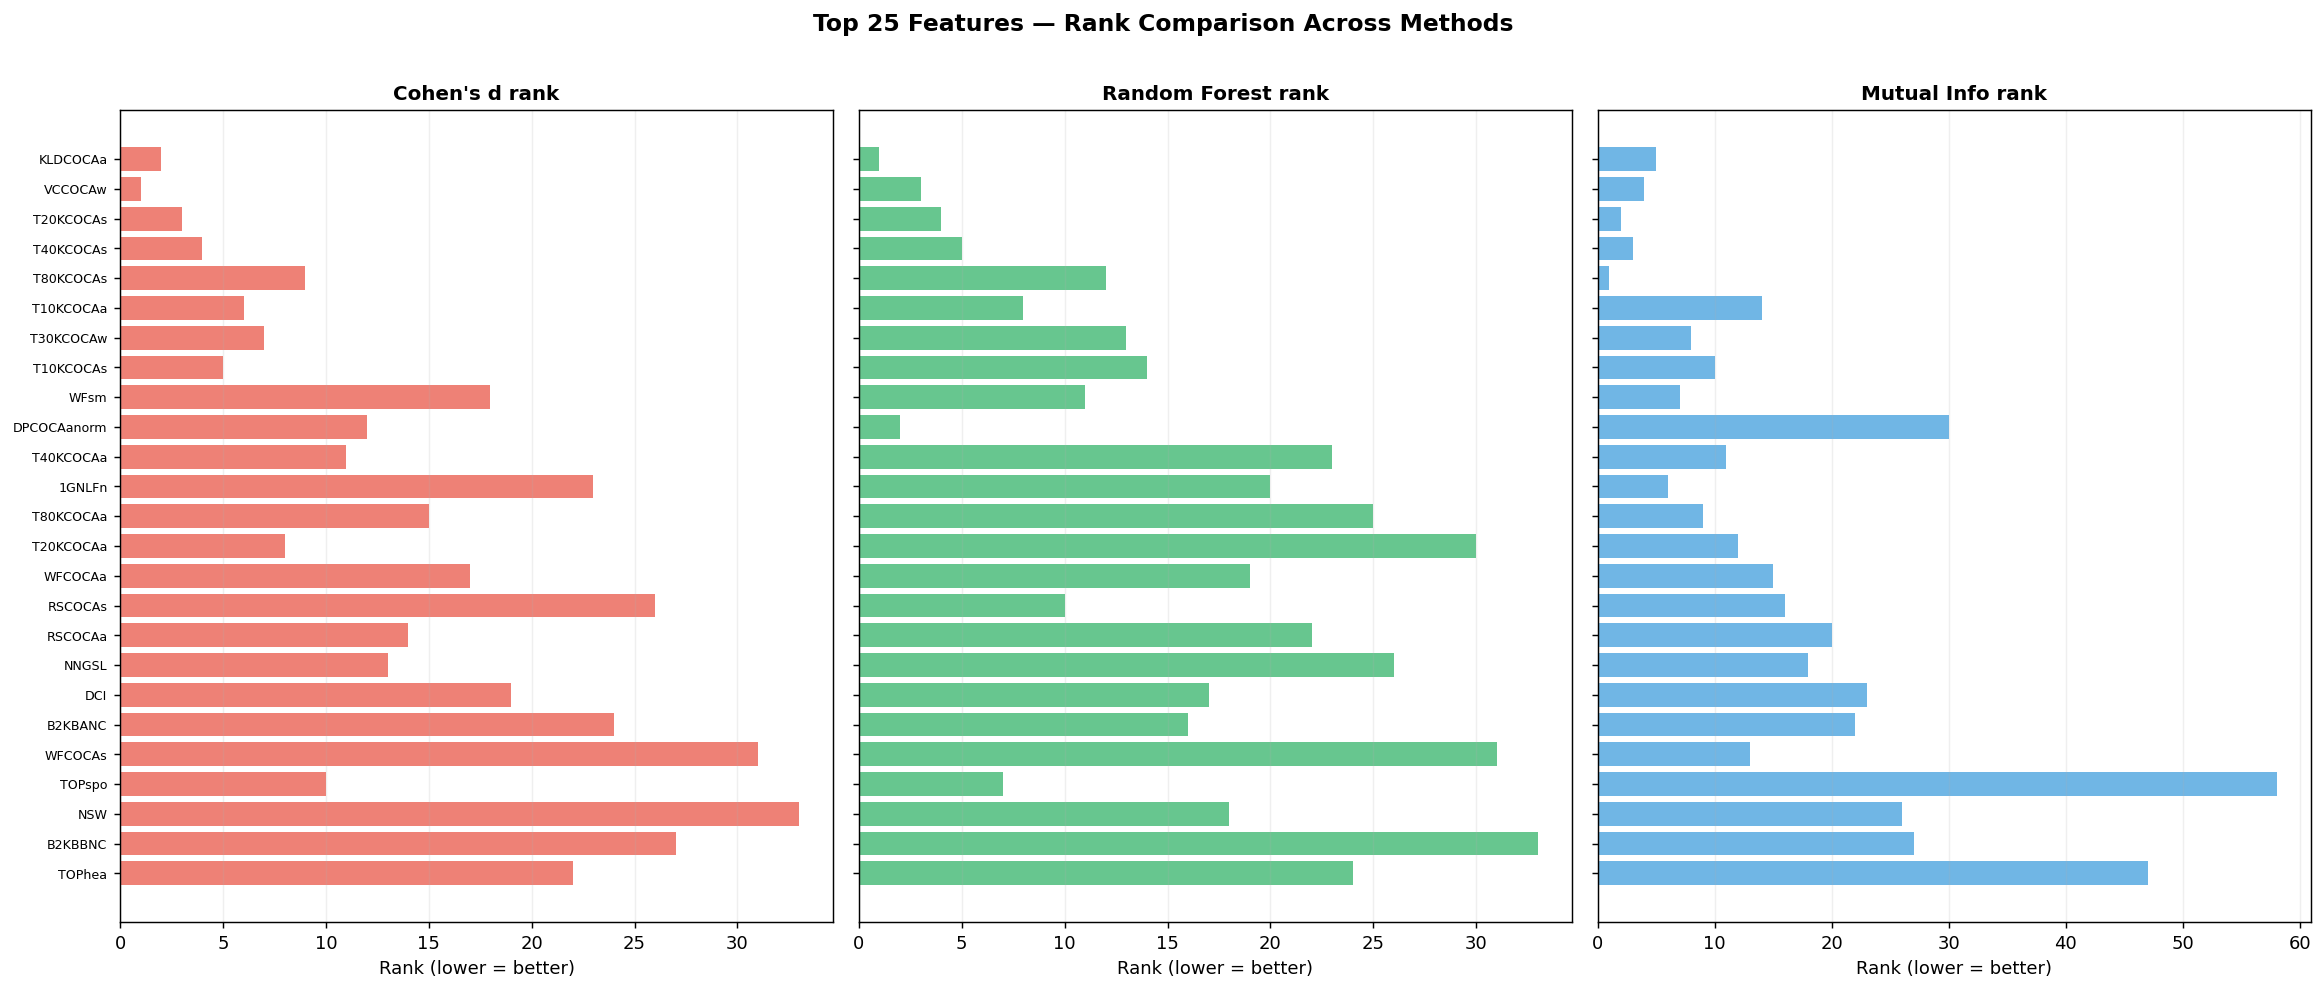

In [17]:
# ============================================================
# 6.3  Visualise consensus ranking
# ============================================================
top_vis = consensus.head(N_SELECT)

fig, axes = plt.subplots(1, 3, figsize=(18, max(6, N_SELECT * 0.3)), sharey=True)

methods = [
    ('rank_effect', "Cohen's d rank", '#E74C3C'),
    ('rank_rf', 'Random Forest rank', '#27AE60'),
    ('rank_mi', 'Mutual Info rank', '#3498DB'),
]

for ax, (col, title, color) in zip(axes, methods):
    ax.barh(range(N_SELECT), top_vis[col], color=color, alpha=0.7)
    ax.set_yticks(range(N_SELECT))
    ax.set_yticklabels(top_vis['feature'], fontsize=7)
    ax.set_xlabel('Rank (lower = better)')
    ax.set_title(title)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.2)

plt.suptitle(f'Top {N_SELECT} Features — Rank Comparison Across Methods',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('cymo_feature_selection_consensus.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7 — Box plots of the final selected features

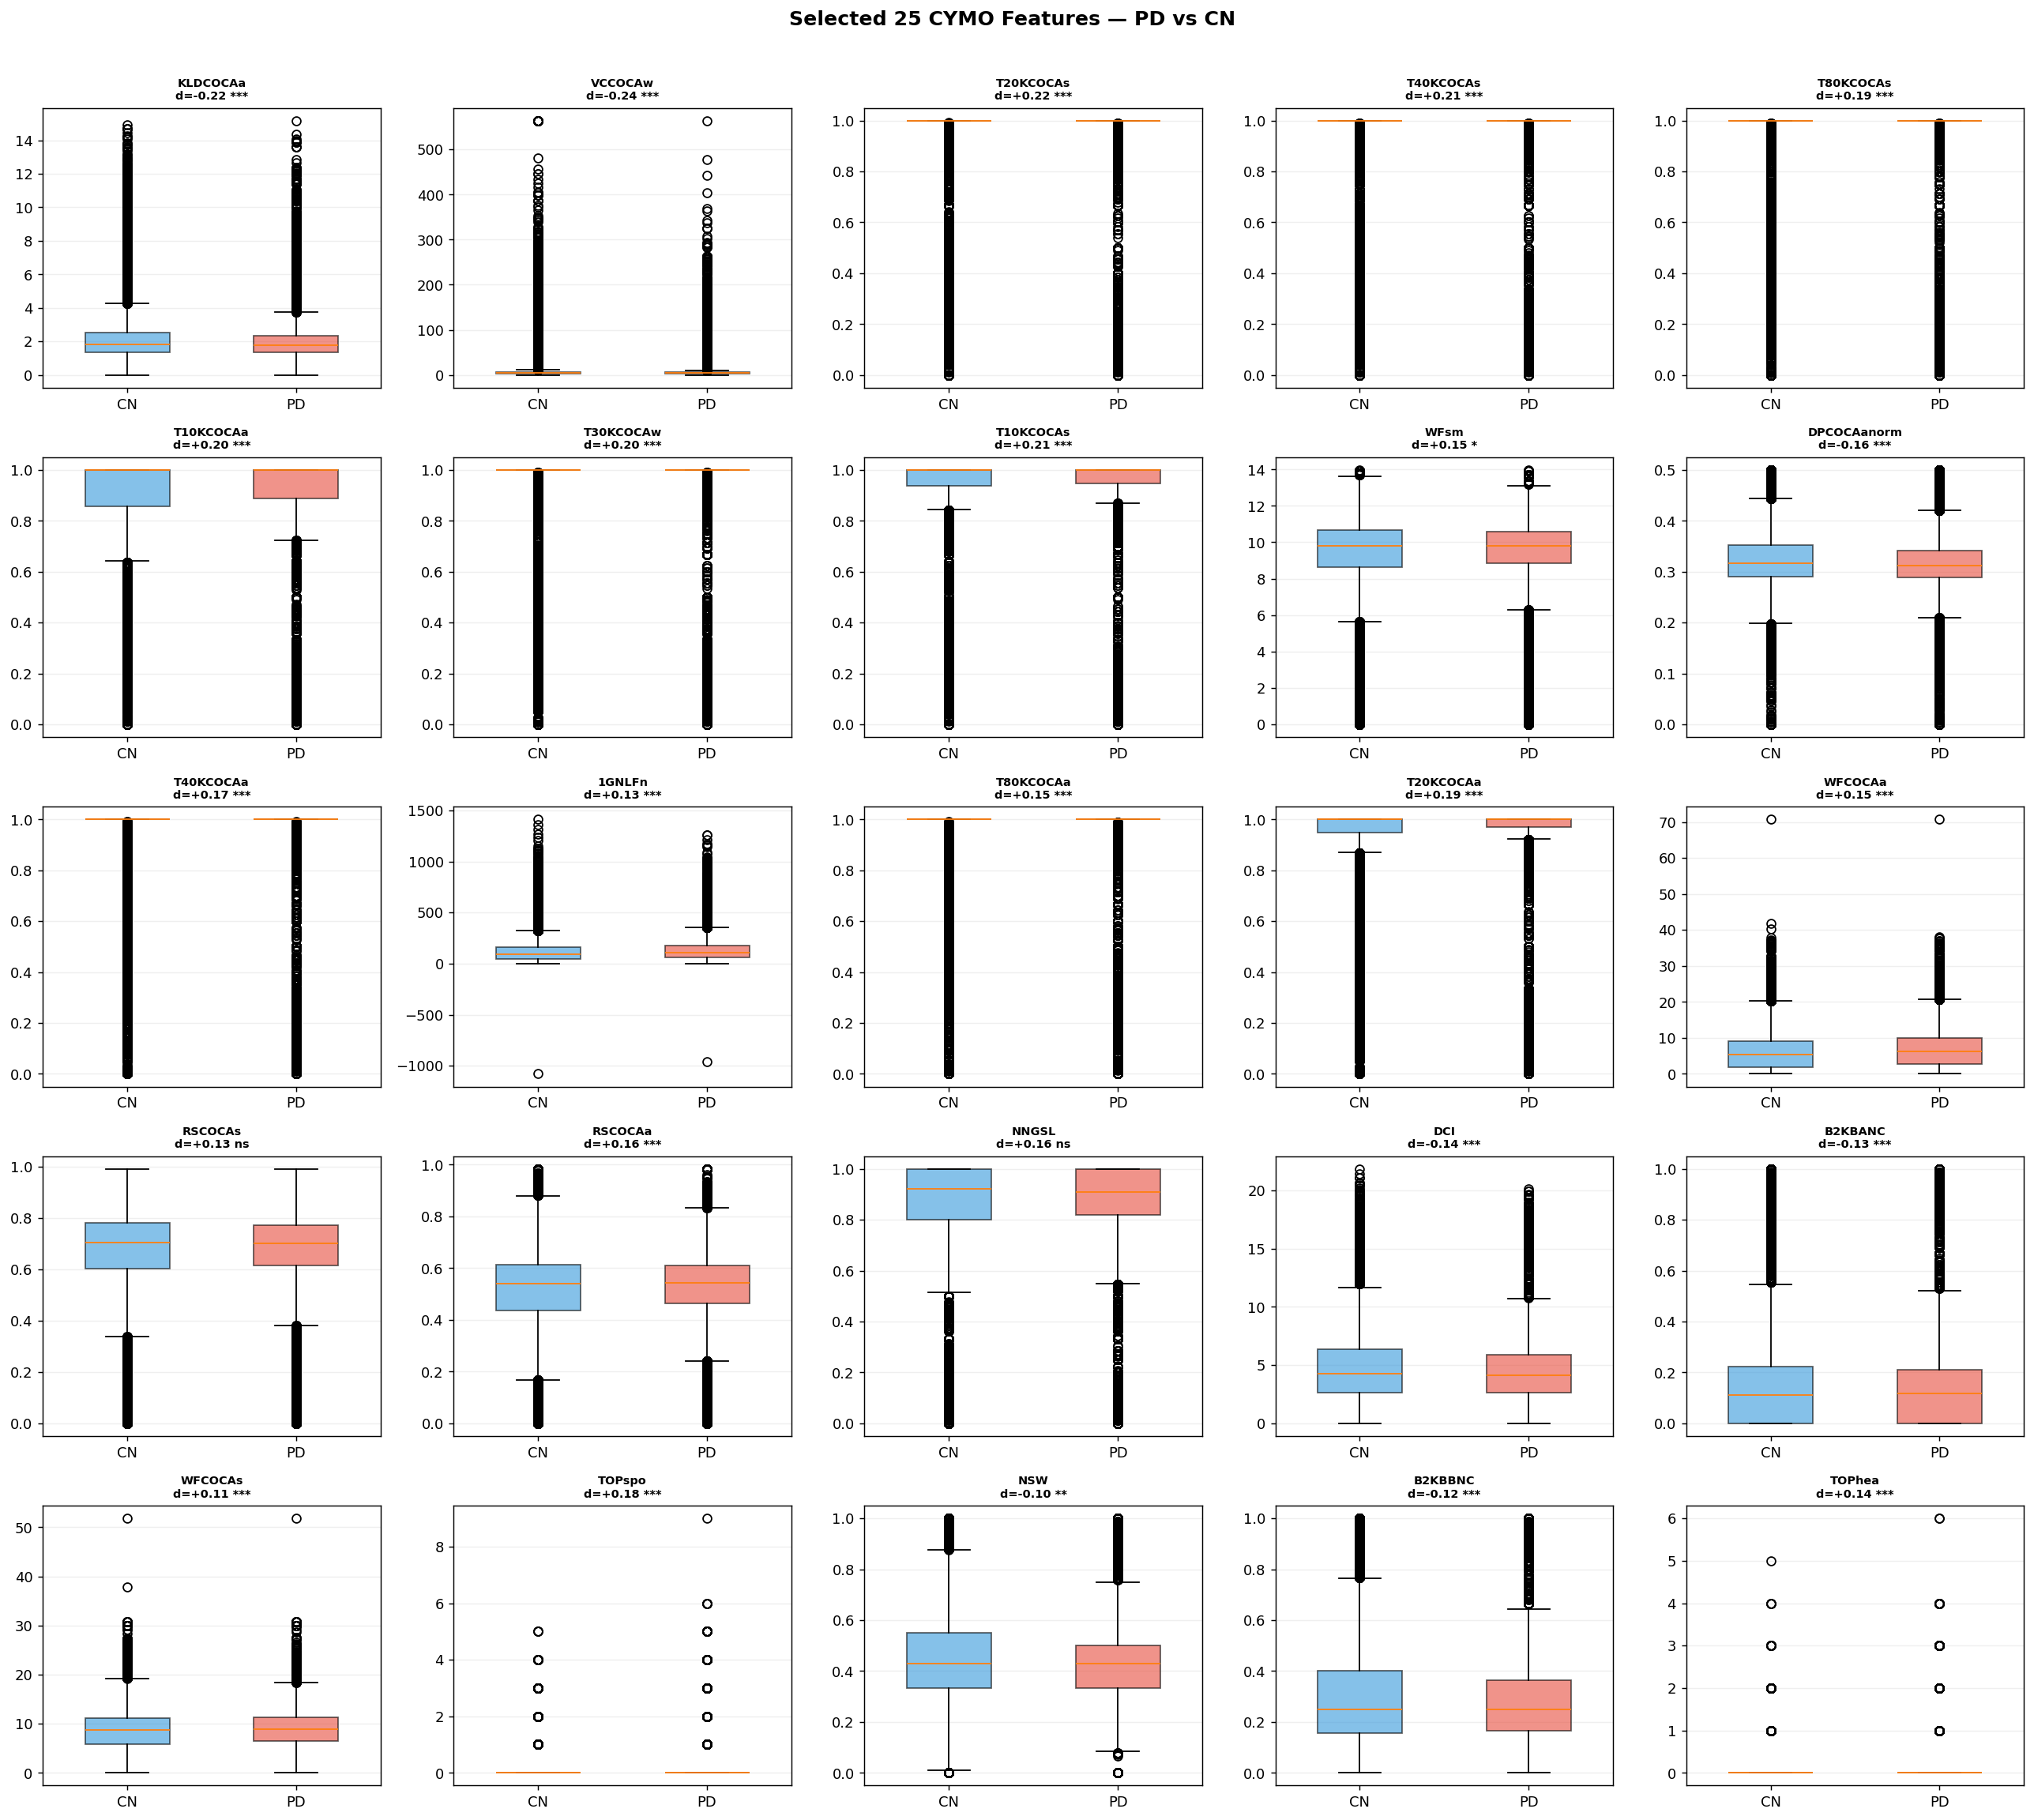

In [18]:
# ============================================================
# 7.  Box plots: CN vs PD for selected features
# ============================================================
n_rows = (N_SELECT + 4) // 5

fig, axes = plt.subplots(n_rows, 5, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

for idx, feat in enumerate(final_features):
    ax = axes[idx]
    cn = df[df['group'] == 'CN'][feat].dropna()
    pd_vals = df[df['group'] == 'PD'][feat].dropna()
    
    bp = ax.boxplot([cn, pd_vals], labels=['CN', 'PD'], patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor('#3498DB')
    bp['boxes'][1].set_facecolor('#E74C3C')
    for box in bp['boxes']:
        box.set_alpha(0.6)
    
    row = uni_df[uni_df['feature'] == feat]
    if len(row) > 0:
        row = row.iloc[0]
        sig = '***' if row['p_bonferroni'] < 0.001 else '**' if row['p_bonferroni'] < 0.01 else '*' if row['p_bonferroni'] < 0.05 else 'ns'
        ax.set_title(f'{feat}\nd={row["cohens_d"]:+.2f} {sig}', fontsize=8)
    else:
        ax.set_title(feat, fontsize=8)
    ax.grid(axis='y', alpha=0.2)

# Hide empty axes
for idx in range(len(final_features), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'Selected {N_SELECT} CYMO Features — PD vs CN',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('cymo_selected_features_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8 — Save results

In [19]:
# ============================================================
# 8.  Save everything
# ============================================================

# Full univariate results
uni_df.to_csv('cymo_univariate_results.csv', index=False)
print(f'Saved: cymo_univariate_results.csv ({len(uni_df)} features)')

# Consensus ranking
consensus.to_csv('cymo_consensus_ranking.csv', index=False)
print(f'Saved: cymo_consensus_ranking.csv ({len(consensus)} features)')

# Final selected features
final_df = consensus.head(N_SELECT)[['feature', 'avg_rank', 'rank_effect',
                                      'rank_rf', 'rank_mi', 'cohens_d',
                                      'p_bonferroni', 'direction']]
final_df.to_csv('cymo_final_selected_features.csv', index=False)
print(f'Saved: cymo_final_selected_features.csv ({N_SELECT} features)')

# Extracted data with only selected features (for model training)
model_df = df[['TID', 'group', 'subject', 'video_id', 'label',
               'years_from_diagnosis', 'before_after'] + final_features]
model_df.to_csv('cymo_selected_features_data.csv', index=False)
print(f'Saved: cymo_selected_features_data.csv ({len(model_df)} rows × {len(model_df.columns)} cols)')
print(f'  → Use this file for model training')

Saved: cymo_univariate_results.csv (345 features)
Saved: cymo_consensus_ranking.csv (194 features)
Saved: cymo_final_selected_features.csv (25 features)
Saved: cymo_selected_features_data.csv (149546 rows × 32 cols)
  → Use this file for model training


---
## Summary of Feature Selection Methods

| Method | What it does | Strengths | Weaknesses |
|--------|-------------|-----------|------------|
| **Cohen's d** | Measures standardised group difference | Simple, interpretable, no model needed | Only captures linear differences |
| **Mann-Whitney U** | Tests if distributions differ significantly | Non-parametric, no normality assumption | p-value depends on sample size |
| **Variance threshold** | Removes features with no variation | Eliminates obviously useless features | Doesn't consider the label |
| **Correlation pruning** | Removes redundant features | Reduces multicollinearity | Arbitrary threshold choice |
| **Random Forest** | Trains a model, ranks by importance | Captures non-linear relationships | Can be unstable with small data |
| **Mutual Information** | Measures statistical dependency with label | Captures non-linear, non-monotonic effects | Sensitive to binning/estimation |
| **Consensus ranking** | Averages ranks from all methods | Robust — features must rank well in multiple views | May miss method-specific gems |

### Next steps
1. Review the selected features — do they make clinical sense?
2. Look up the CYMO documentation for what each selected metric measures
3. Train classification models (logistic regression, SVM, Random Forest) using `cymo_selected_features_data.csv`
4. Use **subject-level aggregation** before training (average features per subject) to avoid data leakage
5. Evaluate with stratified cross-validation